# 10 Quant Finance Case Studies (Runnable Python + yfinance)


> Notes on realism: These are educational backtests (no slippage, simplified fills). For production, you’d add transaction costs, survivorship checks, and execution rules.


## 0) Install and imports

If you run this locally, install dependencies first:

```bash
pip install yfinance pandas numpy matplotlib
```


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

np.set_printoptions(suppress=True)
pd.set_option("display.max_rows", 30)
pd.set_option("display.max_columns", 30)


## Shared helpers (data, returns, metrics)

These functions are used throughout the notebook.

In [10]:
def download_prices(tickers, start="2016-01-01", end=None):
    """Download adjusted close prices from yfinance."""
    data = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=False)
    if isinstance(tickers, str):
        tickers = [tickers]
    # yfinance returns MultiIndex columns when multiple tickers
    if isinstance(data.columns, pd.MultiIndex):
        prices = data["Close"].copy()
    else:
        prices = data[["Close"]].rename(columns={"Close": tickers[0]})
    prices = prices.dropna(how="all")
    return prices

def to_returns(prices):
    """Simple daily returns."""
    return prices.pct_change().dropna()

def ann_return(r, periods=252):
    return (1 + r).prod() ** (periods / len(r)) - 1

def ann_vol(r, periods=252):
    return r.std() * np.sqrt(periods)

def sharpe(r, rf=0.0, periods=252):
    excess = r - rf/periods
    vol = excess.std() * np.sqrt(periods)
    return (excess.mean() * periods) / (vol + 1e-12)

def max_drawdown(equity_curve):
    ec = equity_curve.dropna()
    peak = ec.cummax()
    dd = ec / peak - 1.0
    return dd.min()

def summary_stats(returns, name="Strategy"):
    eq = (1 + returns).cumprod()
    stats = {
        "Name": name,
        "Ann.Return": ann_return(returns),
        "Ann.Vol": ann_vol(returns),
        "Sharpe": sharpe(returns),
        "MaxDD": max_drawdown(eq),
        "Start": str(returns.index[0].date()),
        "End": str(returns.index[-1].date()),
        "Days": int(len(returns))
    }
    return pd.Series(stats)

def plot_equity(returns_dict, title="Equity Curves"):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    plt.figure()
    for k, r in returns_dict.items():
        # Coerce to 1-D Series
        if isinstance(r, pd.DataFrame):
            if r.shape[1] != 1:
                raise ValueError(f"{k} has {r.shape[1]} columns; pass a Series or single column.")
            r = r.iloc[:, 0]

        r = pd.Series(r).dropna()
        eq = (1 + r).cumprod()

        x = eq.index.to_numpy()      # <-- key fix
        y = eq.to_numpy()            # already good
        plt.plot(x, y, label=k)

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Equity (Start = 1.0)")
    plt.legend()
    plt.show()


## 1) Case Study — Data pipeline: prices → returns → rolling stats

**When to use:** any chapter that introduces “clean data” and basic diagnostics.

**What you’ll build:** log returns, rolling volatility, rolling correlation heatmap (latest window).


In [3]:
# Parameters
P = {
    "tickers": ["SPY", "TLT", "GLD"],
    "start": "2016-01-01",
    "vol_window": 20,
    "corr_window": 60,
}

prices = download_prices(P["tickers"], start=P["start"])
rets = to_returns(prices)

log_rets = np.log(prices).diff().dropna()
roll_vol = log_rets.rolling(P["vol_window"]).std() * np.sqrt(252)

# Latest rolling correlation matrix
corr = log_rets.rolling(P["corr_window"]).corr()
latest_date = corr.index.get_level_values(0).max()
latest_corr = corr.loc[latest_date].unstack()

display(prices.tail())
display(roll_vol.tail())
display(latest_corr)


Ticker,GLD,SPY,TLT
Date,,,
2026-01-16,421.290009,691.659973,87.800003
2026-01-20,437.230011,677.580017,86.650002
2026-01-21,443.600006,685.400024,87.309998
2026-01-22,451.790009,688.979980,87.690002
2026-01-23,458.000000,689.229980,87.930000


Ticker,GLD,SPY,TLT
Date,,,
2026-01-16,0.236864,0.072942,0.071643
2026-01-20,0.265666,0.104281,0.083755
2026-01-21,0.267546,0.107342,0.087860
2026-01-22,0.264075,0.106674,0.088896
2026-01-23,0.264278,0.105486,0.089225


Ticker  Ticker
GLD     GLD       1.000000
        SPY       0.185005
        TLT      -0.108615
SPY     GLD       0.185005
        SPY       1.000000
        TLT       0.324767
TLT     GLD      -0.108615
        SPY       0.324767
        TLT       1.000000
dtype: float64

* Rolling volatility plot shows how market risk changes over time rather than staying constant. Spikes usually coincide with crises or regime shifts.

* Rolling correlation matrix shows how diversification can disappear exactly when it is most needed. Assets that appear weakly correlated in calm periods often become highly correlated during stress.

This case shows that quantitative research starts long before any “alpha idea.” Clean price series, consistent return definitions, and rolling diagnostics such as volatility and correlation are the foundation of every strategy. We should take away that most backtest errors and false signals originate from data handling, not from model sophistication. A disciplined data pipeline is itself a competitive advantage.

## 2) Case Study — Trend following: SMA crossover + simple position sizing

**Mechanism:** long when fast SMA > slow SMA, else cash.

**Why it’s useful:** simplest way to explain signals, lookahead avoidance (shift), and evaluation.


,Name,Ann.Return,Ann.Vol,Sharpe,MaxDD,Start,End,Days
0,Buy&Hold,0.139504,0.171912,0.846012,-0.337173,2010-01-05,2026-01-23,4038
1,SMA Trend,0.085215,0.119251,0.745757,-0.219153,2010-01-05,2026-01-23,4038


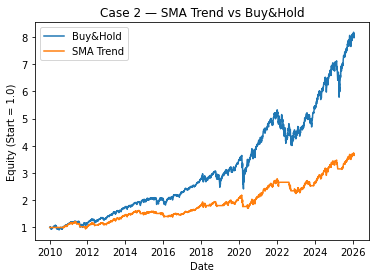

In [11]:
# Parameters
P = {"ticker": "SPY", "start": "2010-01-01", "fast": 20, "slow": 100}

prices = download_prices(P["ticker"], start=P["start"])[P["ticker"]]
r = prices.pct_change().dropna()

fast = prices.rolling(P["fast"]).mean()
slow = prices.rolling(P["slow"]).mean()

signal = (fast > slow).astype(int)
pos = signal.shift(1).reindex(r.index).fillna(0)  # avoid lookahead
strat = pos * r

stats = pd.DataFrame([
    summary_stats(r, "Buy&Hold"),
    summary_stats(strat, "SMA Trend")
])
display(stats)

plot_equity({"Buy&Hold": r, "SMA Trend": strat}, title="Case 2 — SMA Trend vs Buy&Hold")


* Buy & Hold curve reflects full exposure to market drawdowns and recoveries.

* SMA Trend curve shows smoother behavior, with capital preserved during prolonged downtrends and participation during sustained uptrends.

When the trend strategy underperforms, it is usually during sideways or choppy markets where trends fail to persist.

This example demonstrates how a simple rule-based strategy can capture long-term market trends while avoiding the full drawdowns of buy-and-hold. More importantly, it teaches core structural principles: signal generation, lookahead avoidance via shifting, and systematic evaluation. We should understand that complexity is not required for robustness. Clarity and discipline often matter more.

## 3) Case Study — ETF momentum rotation (winner-takes-all)

**Mechanism:** every rebalance date, compute trailing return over lookback window; hold the best ETF until next rebalance.

**Good for:** macro-style chapters (risk-on/risk-off proxies).


,Name,Ann.Return,Ann.Vol,Sharpe,MaxDD,Start,End,Days
0,SPY,0.139504,0.171912,0.846012,-0.337173,2010-01-05,2026-01-23,4038
1,ETF Rotation,0.075463,0.181306,0.492183,-0.314224,2010-01-05,2026-01-23,4038


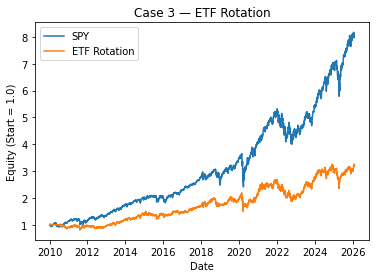

In [12]:
# Parameters
P = {
    "tickers": ["SPY", "QQQ", "IWM", "EFA", "TLT"],
    "start": "2010-01-01",
    "lookback": 126,     # ~6 months
    "rebalance": 21      # ~monthly
}

prices = download_prices(P["tickers"], start=P["start"])
rets = to_returns(prices)

# Rebalance dates: every N trading days
dates = rets.index
rebalance_idx = np.arange(P["lookback"], len(dates), P["rebalance"])

weights = pd.DataFrame(0.0, index=rets.index, columns=rets.columns)

for i in rebalance_idx:
    end = dates[i]
    start = dates[i - P["lookback"]]
    trailing = prices.loc[start:end].iloc[-1] / prices.loc[start:end].iloc[0] - 1
    winner = trailing.idxmax()
    # set weight from next day until next rebalance
    if i + 1 < len(dates):
        next_day = dates[i+1]
        next_i = min(i + P["rebalance"], len(dates)-1)
        stop_day = dates[next_i]
        weights.loc[next_day:stop_day, winner] = 1.0

strat = (weights.shift(1).fillna(0) * rets).sum(axis=1)

stats = pd.DataFrame([
    summary_stats(rets["SPY"], "SPY"),
    summary_stats(strat, "ETF Rotation")
])
display(stats)

plot_equity({"SPY": rets["SPY"], "ETF Rotation": strat}, title="Case 3 — ETF Rotation")


* The strategy equity curve jumps between regimes, reflecting shifts between risk-on assets (equities) and defensive assets (bonds).

* Flat or declining periods indicate frequent switching or unclear leadership among assets.

ETF rotation illustrates how relative performance can be used to express macro and regime views without forecasting fundamentals. The key lesson is that allocation itself can be a signal: choosing which asset to hold often matters more than timing individual entries. We also learn why rebalance frequency and lookback choice materially affect turnover and drawdowns.

## 4) Case Study — Cross-sectional momentum (top-K equal weight)

**Mechanism:** rank a basket by trailing return, hold top-K equally.

**Why it’s important:** introduces cross-sectional thinking (ranking assets against each other).


,Name,Ann.Return,Ann.Vol,Sharpe,MaxDD,Start,End,Days
0,SPY,0.139504,0.171912,0.846012,-0.337173,2010-01-05,2026-01-23,4038
1,Top-K MOM,0.105413,0.134829,0.810993,-0.326743,2010-01-05,2026-01-23,4038


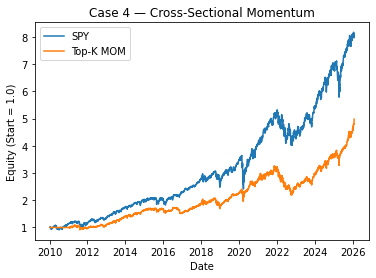

In [13]:
# Parameters
P = {
    "tickers": ["SPY", "QQQ", "IWM", "EFA", "EEM", "TLT", "GLD"],
    "start": "2010-01-01",
    "lookback": 252,
    "rebalance": 21,
    "top_k": 3
}

prices = download_prices(P["tickers"], start=P["start"])
rets = to_returns(prices)

dates = rets.index
rebalance_idx = np.arange(P["lookback"], len(dates), P["rebalance"])
weights = pd.DataFrame(0.0, index=rets.index, columns=rets.columns)

for i in rebalance_idx:
    end = dates[i]
    start = dates[i - P["lookback"]]
    trailing = prices.loc[start:end].iloc[-1] / prices.loc[start:end].iloc[0] - 1
    winners = trailing.sort_values(ascending=False).head(P["top_k"]).index.tolist()
    w = 1.0 / len(winners)
    if i + 1 < len(dates):
        next_day = dates[i+1]
        next_i = min(i + P["rebalance"], len(dates)-1)
        stop_day = dates[next_i]
        weights.loc[next_day:stop_day, winners] = w

strat = (weights.shift(1).fillna(0) * rets).sum(axis=1)

stats = pd.DataFrame([summary_stats(rets["SPY"], "SPY"), summary_stats(strat, "Top-K MOM")])
display(stats)
plot_equity({"SPY": rets["SPY"], "Top-K MOM": strat}, title="Case 4 — Cross-Sectional Momentum")


* The equity curve is typically smoother than Case 3 because capital is spread across multiple winners.

* Drawdowns are often smaller, but upside may also be slightly muted compared to single-asset bets.

This case generalizes momentum into a portfolio construction problem rather than a single-asset bet. By ranking assets against each other, the strategy reduces dependence on absolute market direction and introduces diversification across winners. We should recognize this as the conceptual bridge from “trading signals” to systematic factor investing.

## 5) Case Study — Mean reversion: RSI oversold with time stop

**Mechanism:** buy when RSI < entry, sell when RSI > exit or after N days.

**Teaching point:** “entry + exit + time stop” is a complete micro-strategy template.


,Name,Ann.Return,Ann.Vol,Sharpe,MaxDD,Start,End,Days
0,Buy&Hold,0.139504,0.171912,0.846012,-0.337173,2010-01-05,2026-01-23,4038
1,RSI MR,0.017569,0.085796,0.245807,-0.169835,2010-01-05,2026-01-23,4038


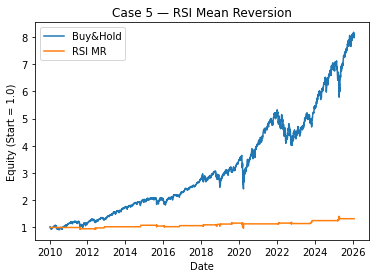

In [14]:
# Parameters
P = {"ticker": "SPY", "start": "2010-01-01", "rsi_n": 14, "entry": 30, "exit": 55, "max_hold": 10}

prices = download_prices(P["ticker"], start=P["start"])[P["ticker"]]
r = prices.pct_change().dropna()

def rsi(series, n=14):
    delta = series.diff()
    up = delta.clip(lower=0)
    down = -delta.clip(upper=0)
    roll_up = up.ewm(alpha=1/n, adjust=False).mean()
    roll_down = down.ewm(alpha=1/n, adjust=False).mean()
    rs = roll_up / (roll_down + 1e-12)
    return 100 - (100 / (1 + rs))

rsi_val = rsi(prices, P["rsi_n"]).reindex(r.index)

pos = pd.Series(0.0, index=r.index)
holding = 0
hold_days = 0

for t in r.index:
    if holding == 0:
        if rsi_val.loc[t] < P["entry"]:
            holding = 1
            hold_days = 0
    else:
        hold_days += 1
        if rsi_val.loc[t] > P["exit"] or hold_days >= P["max_hold"]:
            holding = 0
            hold_days = 0
    pos.loc[t] = holding

pos = pos.shift(1).fillna(0)
strat = pos * r

stats = pd.DataFrame([summary_stats(r, "Buy&Hold"), summary_stats(strat, "RSI MR")])
display(stats)
plot_equity({"Buy&Hold": r, "RSI MR": strat}, title="Case 5 — RSI Mean Reversion")


* The equity curve shows frequent small gains punctuated by occasional sharp drawdowns.

* Flat regions reflect periods where no extreme oversold signals occurred.

Mean reversion strategies highlight a fundamentally different market belief: prices tend to bounce back after short-term extremes. This case teaches how exits and time stops are just as important as entries, especially when trading against momentum. Readers should learn that mean reversion strategies are fragile without disciplined risk controls and regime awareness.

## 6) Case Study — Pairs trading: hedge ratio + spread z-score

**Mechanism:** estimate hedge ratio (OLS slope), compute spread, trade when z-score crosses thresholds.

**Note:** This is simplified; robust versions use rolling regression and stationarity tests.


,0
Name,Pairs Z-Score
Ann.Return,0.000677
Ann.Vol,0.047611
Sharpe,0.037961
MaxDD,-0.203032
Start,2012-01-04
End,2026-01-23
Days,3534


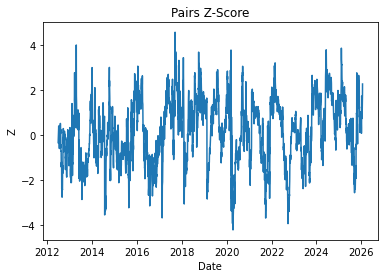

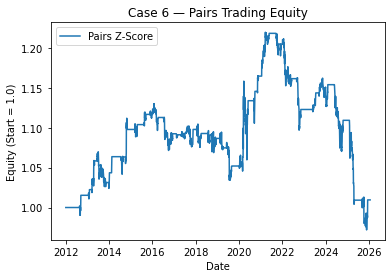

In [17]:
# Parameters
P = {"a": "KO", "b": "PEP", "start": "2012-01-01", "lookback": 120, "entry_z": 2.0, "exit_z": 0.5}

prices = download_prices([P["a"], P["b"]], start=P["start"])
rets = to_returns(prices)

pa = prices[P["a"]]
pb = prices[P["b"]]

pos_a = pd.Series(0.0, index=rets.index)
pos_b = pd.Series(0.0, index=rets.index)

state = 0  # 0 flat, 1 long spread (A - beta*B), -1 short spread
beta_series = pd.Series(index=rets.index, dtype=float)
z_series = pd.Series(index=rets.index, dtype=float)

for i in range(P["lookback"], len(rets.index)):
    end = rets.index[i]
    window = slice(rets.index[i-P["lookback"]], end)
    x = pb.loc[window].values
    y = pa.loc[window].values
    beta = np.polyfit(x, y, 1)[0]
    spread = y - beta * x
    z = (spread[-1] - spread.mean()) / (spread.std() + 1e-12)
    beta_series.loc[end] = beta
    z_series.loc[end] = z

    if state == 0:
        if z > P["entry_z"]:
            state = -1  # short spread: short A, long beta*B
        elif z < -P["entry_z"]:
            state = 1   # long spread: long A, short beta*B
    else:
        if abs(z) < P["exit_z"]:
            state = 0

    # Dollar-neutral weights (approx): A weight = ±0.5, B weight = ∓0.5
    if state == 1:
        pos_a.loc[end] = 0.5
        pos_b.loc[end] = -0.5
    elif state == -1:
        pos_a.loc[end] = -0.5
        pos_b.loc[end] = 0.5
    else:
        pos_a.loc[end] = 0.0
        pos_b.loc[end] = 0.0

pos_a = pos_a.shift(1).fillna(0)
pos_b = pos_b.shift(1).fillna(0)

strat = pos_a * rets[P["a"]] + pos_b * rets[P["b"]]

stats = pd.DataFrame([summary_stats(strat, "Pairs Z-Score")]).T
display(stats)

plt.figure()
plt.plot(z_series.index.to_numpy(), z_series.to_numpy())
plt.title("Pairs Z-Score")
plt.xlabel("Date")
plt.ylabel("Z")
plt.show()

plot_equity({ "Pairs Z-Score": strat }, title="Case 6 — Pairs Trading Equity")


Z-score plot:
* The z-score oscillates around zero, showing deviations from the historical relationship.
* Entry signals occur when the spread reaches statistical extremes; exits occur as it reverts.

Equity curve:
* Returns are typically smoother and less correlated with the market.
* Flat periods indicate times when the relationship offers no exploitable divergence.

Pairs trading introduces market-neutral thinking, where profits depend on relative mispricing rather than market direction. The key takeaway is that modeling relationships between assets can reduce exposure to broad market risk, but only if those relationships remain stable. Readers should appreciate the importance of statistical assumptions and structural breaks in relative-value strategies.

## 7) Case Study — Volatility targeting overlay (scale exposure)

**Mechanism:** estimate realized vol; scale position to target vol; cap leverage.

**Use case:** makes strategies more comparable and often reduces drawdowns.


,Name,Ann.Return,Ann.Vol,Sharpe,MaxDD,Start,End,Days
0,Buy&Hold,0.139504,0.171912,0.846012,-0.337173,2010-01-05,2026-01-23,4038
1,Vol Targeted,0.102935,0.112902,0.924595,-0.147857,2010-01-05,2026-01-23,4038


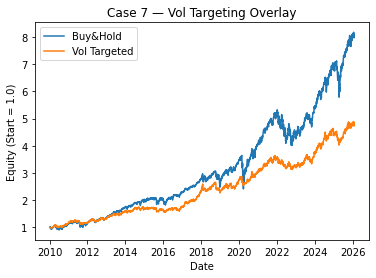

In [18]:
# Parameters
P = {"ticker": "SPY", "start": "2010-01-01", "vol_window": 20, "target_vol": 0.10, "leverage_cap": 2.0}

prices = download_prices(P["ticker"], start=P["start"])[P["ticker"]]
r = prices.pct_change().dropna()

realized = r.rolling(P["vol_window"]).std() * np.sqrt(252)
lev = (P["target_vol"] / (realized + 1e-12)).clip(upper=P["leverage_cap"])
pos = lev.shift(1).fillna(0)

strat = pos * r

stats = pd.DataFrame([summary_stats(r, "Buy&Hold"), summary_stats(strat, "Vol Targeted")])
display(stats)

plot_equity({"Buy&Hold": r, "Vol Targeted": strat}, title="Case 7 — Vol Targeting Overlay")


* The volatility-targeted equity curve grows more steadily than buy-and-hold.
* Drawdowns are visibly compressed during high-volatility periods.

This case shows that risk management can be layered on top of almost any strategy to materially change its behavior. Volatility targeting makes returns more comparable across time and often reduces drawdowns, even when raw returns remain similar. Readers should understand that controlling risk is frequently more impactful than improving raw signal quality.

## 8) Case Study — Risk parity allocation (rolling covariance, inverse risk)

**Mechanism:** estimate rolling covariance; compute weights that equalize risk contributions (approx).

**Note:** True risk parity solves a nonlinear optimization. Here we provide a practical approximation:
- start with inverse-vol weights
- optionally refine via a simple iterative adjustment


,Name,Ann.Return,Ann.Vol,Sharpe,MaxDD,Start,End,Days
0,SPY,0.139504,0.171912,0.846013,-0.337173,2010-01-05,2026-01-23,4038
1,Inv-Vol (RP-ish),0.064764,0.069208,0.941442,-0.207760,2010-01-05,2026-01-23,4038


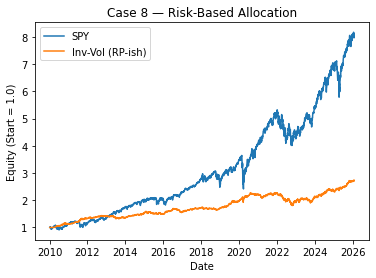

In [19]:
# Parameters
P = {
    "tickers": ["SPY", "TLT", "GLD", "IEF"],
    "start": "2010-01-01",
    "rebalance": 21,
    "cov_window": 60
}

prices = download_prices(P["tickers"], start=P["start"])
rets = to_returns(prices)

def inverse_vol_weights(window_returns):
    vol = window_returns.std()
    w = 1.0 / (vol + 1e-12)
    return w / w.sum()

weights = pd.DataFrame(index=rets.index, columns=rets.columns, dtype=float)
dates = rets.index
rebalance_idx = np.arange(P["cov_window"], len(dates), P["rebalance"])

for i in rebalance_idx:
    end = dates[i]
    window = rets.loc[dates[i-P["cov_window"]]:end]
    w = inverse_vol_weights(window)
    if i + 1 < len(dates):
        next_day = dates[i+1]
        next_i = min(i + P["rebalance"], len(dates)-1)
        stop_day = dates[next_i]
        weights.loc[next_day:stop_day] = w.values

weights = weights.fillna(method="ffill").fillna(0)
strat = (weights.shift(1).fillna(0) * rets).sum(axis=1)

stats = pd.DataFrame([summary_stats(rets["SPY"], "SPY"), summary_stats(strat, "Inv-Vol (RP-ish)")])
display(stats)
plot_equity({"SPY": rets["SPY"], "Inv-Vol (RP-ish)": strat}, title="Case 8 — Risk-Based Allocation")


* The risk-based portfolio typically lags equities in strong bull markets.
* It outperforms or preserves capital during stress periods due to diversification and lower exposure to volatile assets.

Risk-based allocation reframes portfolio construction away from capital weights and toward risk contributions. This example teaches that diversification is about risk, not number of assets. Readers should learn why portfolios that look diversified on paper can still be dominated by a single risk factor, and how systematic weighting can address that.

## 9) Case Study — Covered call overlay (simplified using yfinance option chains)

**Mechanism:** hold underlying; once per month sell ~30DTE call near ATM.

**Important simplifications:**
- Uses option chain snapshots (not full historical option surfaces).
- Backtest approximates call premium using chain data available at each roll date.
- This is best for **education** and explaining payoff decomposition, not for production accuracy.

If yfinance fails to fetch options for your region/session, switch the ticker to a very liquid one (e.g., SPY, AAPL) or skip this section.


,Name,Ann.Return,Ann.Vol,Sharpe,MaxDD,Start,End,Days
0,Buy&Hold,0.110276,0.179312,0.672856,-0.244711,2022-01-04,2026-01-23,1017
1,Covered Call (Approx),0.110368,0.179312,0.673320,-0.244711,2022-01-04,2026-01-23,1017


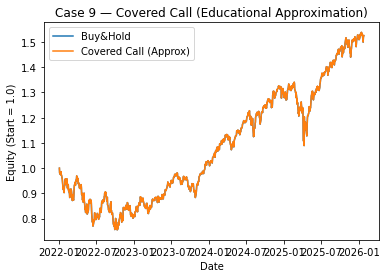

In [20]:
# Parameters
P = {"ticker": "SPY", "start": "2022-01-01", "roll_days": 21, "target_dte": 30}

prices = download_prices(P["ticker"], start=P["start"])[P["ticker"]]
r = prices.pct_change().dropna()

def nearest_expiry(tkr, target_dte=30):
    expiries = tkr.options
    if not expiries:
        return None
    # pick expiry with DTE closest to target
    today = pd.Timestamp.utcnow().normalize()
    best = None
    best_dist = 1e9
    for e in expiries:
        dte = (pd.Timestamp(e) - today).days
        dist = abs(dte - target_dte)
        if dist < best_dist and dte > 5:
            best = e
            best_dist = dist
    return best

# Educational backtest: roll monthly, collect premium, cap upside between rolls
tkr = yf.Ticker(P["ticker"])
dates = r.index

roll_idx = np.arange(0, len(dates), P["roll_days"])
premium = pd.Series(0.0, index=dates)
cap_level = pd.Series(np.nan, index=dates)

current_strike = None
current_premium = 0.0

for k, i in enumerate(roll_idx):
    dt = dates[i]
    spot = prices.loc[dt]
    # Try fetch option chain at runtime (uses current chain; not historical)
    # We'll still use it as an educational approximation.
    exp = None
    try:
        exp = nearest_expiry(tkr, P["target_dte"])
    except Exception:
        exp = None

    if exp is None:
        # If options unavailable, just skip premium and act like buy&hold for this month
        current_strike = None
        current_premium = 0.0
    else:
        try:
            chain = tkr.option_chain(exp).calls
            # choose strike closest to spot
            chain["dist"] = (chain["strike"] - float(spot)).abs()
            row = chain.sort_values(["dist"]).iloc[0]
            # premium approximation: midpoint of bid/ask if available, else lastPrice
            bid, ask, last = row.get("bid", np.nan), row.get("ask", np.nan), row.get("lastPrice", np.nan)
            if pd.notna(bid) and pd.notna(ask) and ask > 0:
                prem = float((bid + ask) / 2.0)
            else:
                prem = float(last) if pd.notna(last) else 0.0
            current_strike = float(row["strike"])
            current_premium = max(0.0, prem) / float(spot)  # as fraction of spot
        except Exception:
            current_strike = None
            current_premium = 0.0

    # Apply for the next interval
    start = dt
    end = dates[min(i + P["roll_days"] - 1, len(dates)-1)]
    premium.loc[start:end] = current_premium
    if current_strike is not None:
        cap_level.loc[start:end] = current_strike

# Covered call monthly return approximation:
# underlying return capped at strike, plus premium collected at start of period.
cc_ret = pd.Series(0.0, index=dates)

for i in range(1, len(dates)):
    dt = dates[i]
    prev = dates[i-1]
    spot_prev = prices.loc[prev]
    spot_now = prices.loc[dt]
    if pd.isna(cap_level.loc[prev]):
        cc_ret.loc[dt] = (spot_now/spot_prev) - 1
    else:
        cap = cap_level.loc[prev]
        # cap payoff: min(spot_now, cap) relative to spot_prev
        capped = min(float(spot_now), float(cap)) / float(spot_prev) - 1
        # premium is accrued (simplified: add daily portion)
        cc_ret.loc[dt] = capped + (premium.loc[prev] / P["roll_days"])

cc_ret = cc_ret.dropna()

stats = pd.DataFrame([summary_stats(r.loc[cc_ret.index], "Buy&Hold"),
                      summary_stats(cc_ret, "Covered Call (Approx)")])
display(stats)

plot_equity({"Buy&Hold": r.loc[cc_ret.index], "Covered Call (Approx)": cc_ret},
            title="Case 9 — Covered Call (Educational Approximation)")


* The covered call curve rises steadily in sideways markets.
* It underperforms buy-and-hold during sharp rallies due to capped upside.
* Drawdowns may be slightly reduced due to option premium income.

Covered calls demonstrate how options can reshape return distributions without changing the underlying asset. The strategy trades upside convexity for income, making it suitable for range-bound or mildly bullish markets. Readers should learn to think in terms of payoff engineering rather than directional prediction, and to recognize the hidden costs of “income” strategies.


## 10) Case Study — Commodities trend (ETF proxy) + regime filter

Since historical futures data/roll handling is non-trivial, we use **commodity ETFs** as proxies (fully supported by yfinance).

**Mechanism:** trend-following on a commodity basket (e.g., DBC, GLD, USO) with a simple risk-off filter.


,Name,Ann.Return,Ann.Vol,Sharpe,MaxDD,Start,End,Days
0,DBC,0.002439,0.166370,0.098144,-0.637113,2012-01-04,2026-01-23,3534
1,Commodity Trend (Proxy),-0.023621,0.269604,0.046080,-0.668572,2012-01-04,2026-01-23,3534


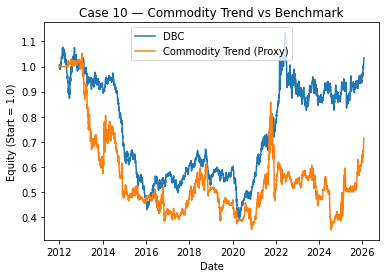

In [23]:
# Parameters
P = {
    "tickers": ["DBC", "GLD", "USO", "UNG"],  # broad commodities, gold, oil, natural gas ETF proxies
    "start": "2012-01-01",
    "lookback": 90,
    "rebalance": 21,
    "risk_off": "IEF",   # when risk-off filter triggers, park here
    "filter_sma": 200
}

tickers_all = P["tickers"] + [P["risk_off"]]
prices = download_prices(tickers_all, start=P["start"])
rets = to_returns(prices)

# Risk-off filter based on SPY vs 200DMA (you can swap this to your preference)
spy = download_prices("SPY", start=P["start"])["SPY"]
spy_fast = spy.rolling(P["filter_sma"]).mean()
risk_on = (spy > spy_fast).reindex(rets.index).fillna(False)

dates = rets.index
rebalance_idx = np.arange(P["lookback"], len(dates), P["rebalance"])
weights = pd.DataFrame(0.0, index=rets.index, columns=rets.columns)

for i in rebalance_idx:
    end = dates[i]
    start = dates[i - P["lookback"]]
    # rank commodity ETFs by trailing return
    trailing = prices.loc[start:end, P["tickers"]].iloc[-1] / prices.loc[start:end, P["tickers"]].iloc[0] - 1
    best = trailing.idxmax()
    if i + 1 < len(dates):
        next_day = dates[i+1]
        next_i = min(i + P["rebalance"], len(dates)-1)
        stop_day = dates[next_i]
        if bool(risk_on.loc[next_day]):
            weights.loc[next_day:stop_day, best] = 1.0
        else:
            weights.loc[next_day:stop_day, P["risk_off"]] = 1.0

strat = (weights.shift(1).fillna(0) * rets).sum(axis=1)
bench = "DBC"

stats = pd.DataFrame([
    summary_stats(rets[bench], bench),
    summary_stats(strat, "Commodity Trend (Proxy)")
])
display(stats)

plot_equity({bench: rets[bench], "Commodity Trend (Proxy)": strat},
            title="Case 10 — Commodity Trend vs Benchmark")


* The strategy equity curve shows episodic growth during strong commodity trends.
* Flat or defensive periods correspond to risk-off regimes where capital is preserved.
* Large moves are infrequent but meaningful.

This final case extends trend-following ideas into commodities while highlighting the importance of regime filters and asset-specific dynamics. Using ETF proxies simplifies implementation but also introduces tracking and structural differences. Readers should take away that strategy logic must adapt to asset class realities, and that macro signals often work best when combined with risk-aware filters.